In [1]:
print("all ok")

all ok


In [3]:
print("subodh")

subodh


PART 1: VECTORS AND MATRICES FUNDAMENTALS

📌 VECTOR (1D array):
2D Vector: [3 4]
3D Vector: [ 1.  -2.   3.5]
Embedding vector (5D): [ 0.21 -0.44  0.89  0.12 -0.67]
Shape: (5,)

📌 MATRIX (2D array):
2×2 Matrix:
[[1 2]
 [3 4]]

3×2 Matrix:
[[1 2]
 [3 4]
 [5 6]]

2×3 Matrix:
[[1 2 3]
 [4 5 6]]


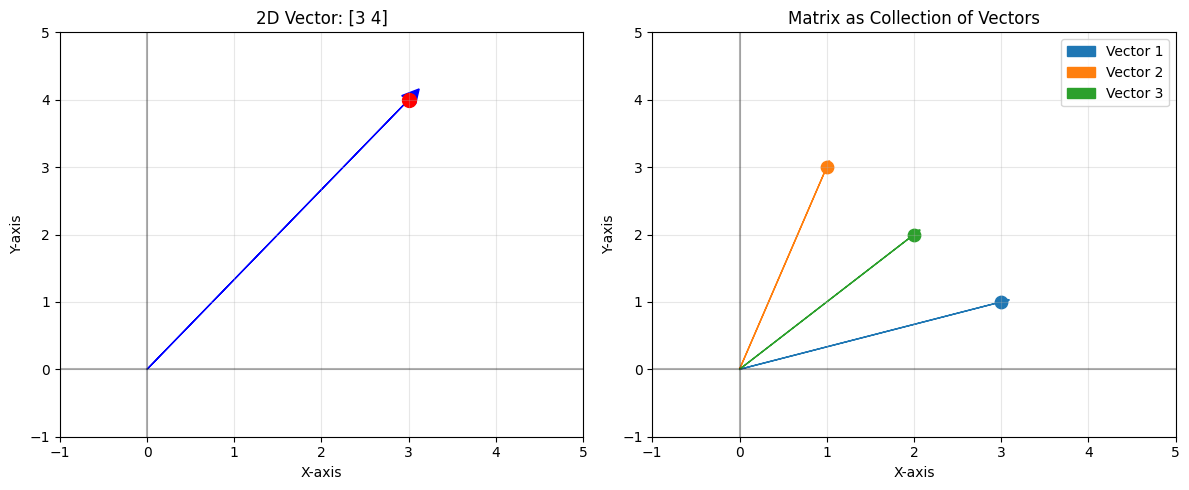


💡 KEY INSIGHT: A matrix is just a collection of vectors!
   - Row vector: shape (1, n)
   - Column vector: shape (n, 1)
   - Embedding = vector with semantic meaning


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns


# ============================================================================
# PART 1: VECTORS AND MATRICES FUNDAMENTALS
# ============================================================================


print("=" * 60)
print("PART 1: VECTORS AND MATRICES FUNDAMENTALS")
print("=" * 60)


# --- VECTOR: A list of numbers representing a point in space ---
print("\n📌 VECTOR (1D array):")
vector_2d = np.array([3, 4])
vector_3d = np.array([1, -2, 3.5])
vector_embedding = np.array([0.21, -0.44, 0.89, 0.12, -0.67])


print(f"2D Vector: {vector_2d}")
print(f"3D Vector: {vector_3d}")
print(f"Embedding vector (5D): {vector_embedding}")
print(f"Shape: {vector_embedding.shape}")


# --- MATRIX: Collection of vectors (2D array) ---
print("\n📌 MATRIX (2D array):")
matrix_2x2 = np.array([[1, 2], 
                       [3, 4]])


matrix_3x2 = np.array([[1, 2],
                       [3, 4],
                       [5, 6]])


matrix_2x3 = np.array([[1, 2, 3],
                       [4, 5, 6]])


print(f"2×2 Matrix:\n{matrix_2x2}")
print(f"\n3×2 Matrix:\n{matrix_3x2}")
print(f"\n2×3 Matrix:\n{matrix_2x3}")


# --- VISUALIZATION: 2D Vector Space ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Plot 2D vector
axes[0].arrow(0, 0, vector_2d[0], vector_2d[1], head_width=0.2, head_length=0.2, 
              fc='blue', ec='blue')
axes[0].scatter(vector_2d[0], vector_2d[1], color='red', s=100)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-1, 5)
axes[0].set_ylim(-1, 5)
axes[0].set_xlabel('X-axis')
axes[0].set_ylabel('Y-axis')
axes[0].set_title(f'2D Vector: {vector_2d}')
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)


# Visualize matrix as multiple vectors
matrix_vectors = np.array([[3, 1], [1, 3], [2, 2]])
for i, vec in enumerate(matrix_vectors):
    axes[1].arrow(0, 0, vec[0], vec[1], head_width=0.1, head_length=0.1, 
                  fc=f'C{i}', ec=f'C{i}', label=f'Vector {i+1}')
    axes[1].scatter(vec[0], vec[1], color=f'C{i}', s=80)


axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-1, 5)
axes[1].set_ylim(-1, 5)
axes[1].set_xlabel('X-axis')
axes[1].set_ylabel('Y-axis')
axes[1].set_title('Matrix as Collection of Vectors')
axes[1].legend()
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='-', alpha=0.3)


plt.tight_layout()
plt.show()


print("\n💡 KEY INSIGHT: A matrix is just a collection of vectors!")
print("   - Row vector: shape (1, n)")
print("   - Column vector: shape (n, 1)")
print("   - Embedding = vector with semantic meaning")



PART 2: WHAT ARE EMBEDDINGS?

🎯 DEFINITION: 
   An embedding is a numerical representation of data (text, image, audio, video)
   that preserves semantic meaning in a dense, high-dimensional vector space.


🔑 KEY PROPERTIES:
   1. DENSE: Most values are non-zero (unlike sparse representations)
   2. HIGH-DIMENSIONAL: Typically 100-2048 dimensions
   3. MEANINGFUL: Similar items have similar vectors
   4. CONTINUOUS: Values are floating-point numbers


📝 EXAMPLE: Word Embeddings

📊 Semantic Relationships:
  king     ↔ queen    | Distance: 0.040 | Similarity: 0.962
  king     ↔ banana   | Distance: 1.811 | Similarity: 0.356
  apple    ↔ banana   | Distance: 0.046 | Similarity: 0.956
  king     ↔ car      | Distance: 1.808 | Similarity: 0.356


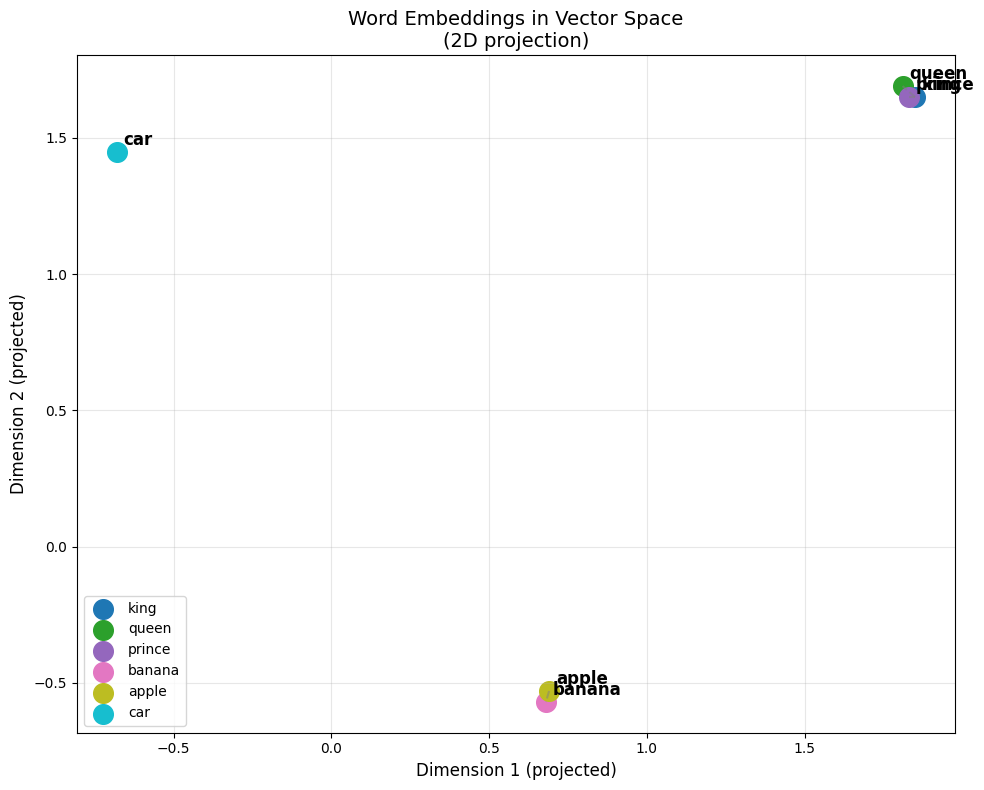


💡 OBSERVATION: Related words (king-queen) are close together!
   Unrelated words (king-banana) are far apart!


In [7]:
# ============================================================================
# PART 2: WHAT ARE EMBEDDINGS?
# ============================================================================


print("\n" + "=" * 60)
print("PART 2: WHAT ARE EMBEDDINGS?")
print("=" * 60)


print("""
🎯 DEFINITION: 
   An embedding is a numerical representation of data (text, image, audio, video)
   that preserves semantic meaning in a dense, high-dimensional vector space.


🔑 KEY PROPERTIES:
   1. DENSE: Most values are non-zero (unlike sparse representations)
   2. HIGH-DIMENSIONAL: Typically 100-2048 dimensions
   3. MEANINGFUL: Similar items have similar vectors
   4. CONTINUOUS: Values are floating-point numbers
""")


# Example: Word embeddings for semantic relationships
print("\n📝 EXAMPLE: Word Embeddings")


# Mock embeddings for different words (in real world, these have 100+ dimensions)
embeddings = {
    "king": np.array([0.95, 0.85, 0.90, 0.80]),
    "queen": np.array([0.93, 0.87, 0.88, 0.82]),
    "prince": np.array([0.94, 0.84, 0.89, 0.81]),
    "banana": np.array([0.12, -0.34, 0.56, -0.23]),
    "apple": np.array([0.15, -0.32, 0.54, -0.21]),
    "car": np.array([-0.45, 0.67, -0.23, 0.78])
}


# Calculate distances
print("\n📊 Semantic Relationships:")
for word1, word2 in [("king", "queen"), ("king", "banana"), ("apple", "banana"), ("king", "car")]:
    vec1 = embeddings[word1]
    vec2 = embeddings[word2]
    distance = np.linalg.norm(vec1 - vec2)
    similarity = 1 / (1 + distance)  # Convert distance to similarity
    print(f"  {word1:8} ↔ {word2:8} | Distance: {distance:.3f} | Similarity: {similarity:.3f}")


# --- VISUALIZATION: Embedding Space (2D projection) ---
# Reduce to 2D for visualization
words = list(embeddings.keys())
vectors_2d = {}
for word, vec in embeddings.items():
    # Simple projection to 2D (in reality, use PCA/t-SNE)
    vectors_2d[word] = np.array([vec[0] + vec[2], vec[1] + vec[3]])


fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(words)))


for i, (word, vec) in enumerate(vectors_2d.items()):
    ax.scatter(vec[0], vec[1], color=colors[i], s=200, label=word)
    ax.annotate(word, (vec[0], vec[1]), fontsize=12, fontweight='bold', 
                xytext=(5, 5), textcoords='offset points')


# Draw lines between related words
related_pairs = [("king", "queen"), ("king", "prince"), ("apple", "banana")]
for w1, w2 in related_pairs:
    v1 = vectors_2d[w1]
    v2 = vectors_2d[w2]
    ax.plot([v1[0], v2[0]], [v1[1], v2[1]], 'gray', linestyle='--', alpha=0.5)


ax.set_xlabel('Dimension 1 (projected)', fontsize=12)
ax.set_ylabel('Dimension 2 (projected)', fontsize=12)
ax.set_title('Word Embeddings in Vector Space\n(2D projection)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


print("\n💡 OBSERVATION: Related words (king-queen) are close together!")
print("   Unrelated words (king-banana) are far apart!")



PART 3: STATIC vs CONTEXTUAL EMBEDDINGS

🔴 STATIC EMBEDDINGS (Word2Vec, FastText):
   - Same vector for a word regardless of context
   - Word-level only
   - Cannot handle polysemy (words with multiple meanings)

🟢 CONTEXTUAL EMBEDDINGS (BERT, Transformer-based):
   - Different vectors based on surrounding context
   - Sentence/document level
   - Understands word sense disambiguation


📝 EXAMPLE: The word 'BANK' in different contexts

🔹 Static Embedding (Word2Vec):
   'bank' in any context → [ 0.5 -0.2  0.8]...

🔹 Contextual Embeddings (BERT):
   'I sat on the river bank' → [ 0.6 -0.1  0.7]...
   'I deposited money in the bank' → [ 0.4 -0.3  0.9]...

📊 Cosine Similarity:
   Static: bank ↔ bank = 1.000 (always identical)
   Contextual: river bank ↔ money bank = 0.630 (different meanings)


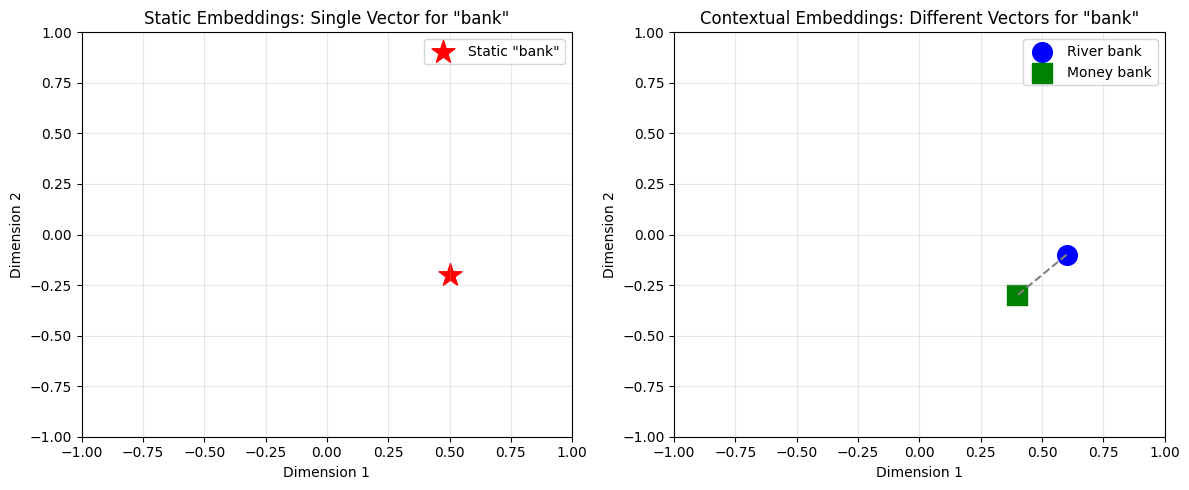

In [8]:
# ============================================================================
# PART 3: STATIC vs CONTEXTUAL EMBEDDINGS
# ============================================================================


print("\n" + "=" * 60)
print("PART 3: STATIC vs CONTEXTUAL EMBEDDINGS")
print("=" * 60)


print("""
🔴 STATIC EMBEDDINGS (Word2Vec, FastText):
   - Same vector for a word regardless of context
   - Word-level only
   - Cannot handle polysemy (words with multiple meanings)
   
🟢 CONTEXTUAL EMBEDDINGS (BERT, Transformer-based):
   - Different vectors based on surrounding context
   - Sentence/document level
   - Understands word sense disambiguation
""")


# Example: The word "bank" has different meanings
print("\n📝 EXAMPLE: The word 'BANK' in different contexts")


# Static embedding (same for both contexts)
static_bank = np.array([0.5, -0.2, 0.8, 0.1, -0.4])


# Contextual embeddings (different based on context)
bank_river = np.array([0.6, -0.1, 0.7, 0.3, 0.2])    # River bank
bank_money = np.array([0.4, -0.3, 0.9, -0.1, -0.6])   # Financial bank


print("\n🔹 Static Embedding (Word2Vec):")
print(f"   'bank' in any context → {static_bank[:3]}...")


print("\n🔹 Contextual Embeddings (BERT):")
print(f"   'I sat on the river bank' → {bank_river[:3]}...")
print(f"   'I deposited money in the bank' → {bank_money[:3]}...")


# Calculate similarity
static_similarity = cosine_similarity([static_bank], [static_bank])[0][0]
context_similarity = cosine_similarity([bank_river], [bank_money])[0][0]


print(f"\n📊 Cosine Similarity:")
print(f"   Static: bank ↔ bank = {static_similarity:.3f} (always identical)")
print(f"   Contextual: river bank ↔ money bank = {context_similarity:.3f} (different meanings)")


# --- VISUALIZATION: Static vs Contextual ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


# Static embeddings visualization
ax1.scatter(static_bank[0], static_bank[1], s=300, c='red', label='Static "bank"', marker='*')
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_xlabel('Dimension 1')
ax1.set_ylabel('Dimension 2')
ax1.set_title('Static Embeddings: Single Vector for "bank"')
ax1.grid(True, alpha=0.3)
ax1.legend()


# Contextual embeddings visualization
ax2.scatter(bank_river[0], bank_river[1], s=200, c='blue', label='River bank', marker='o')
ax2.scatter(bank_money[0], bank_money[1], s=200, c='green', label='Money bank', marker='s')
ax2.plot([bank_river[0], bank_money[0]], [bank_river[1], bank_money[1]], 'gray', linestyle='--')
ax2.set_xlim(-1, 1)
ax2.set_ylim(-1, 1)
ax2.set_xlabel('Dimension 1')
ax2.set_ylabel('Dimension 2')
ax2.set_title('Contextual Embeddings: Different Vectors for "bank"')
ax2.grid(True, alpha=0.3)
ax2.legend()


plt.tight_layout()
plt.show()



PART 4: SEMANTIC SEARCH & SIMILARITY MEASURES

🔍 SEMANTIC SEARCH: Finding information based on MEANING, not just keywords.

   Instead of: "Does document contain word 'car'?"
   We ask:     "Is the document's embedding close to query embedding?"

   This works because semantically similar content has similar embeddings!


📝 SEARCH EXAMPLE:
Query: 'Health benefits of fruits'
Query embedding: [0.82 0.79 0.74]...

1️⃣ COSINE SIMILARITY
Measures the angle between vectors (direction, not magnitude)
Range: -1 to 1 (higher = more similar)
  Doc1: Heart health benefits of fiber     → 0.9998
  Doc2: Fruits reduce cardiovascular disea → 0.9998
  Doc3: New car buying guide 2024          → 0.0815
  Doc4: Best car maintenance tips          → 0.0880
  Doc5: Apple banana fruit salad recipe    → 0.0120

2️⃣ DOT PRODUCT
Measures both magnitude and direction
Higher positive value = more similar
  Doc1: Heart health benefits of fiber     → 2.5646
  Doc2: Fruits reduce cardiovascular disea → 2.5638
  Doc

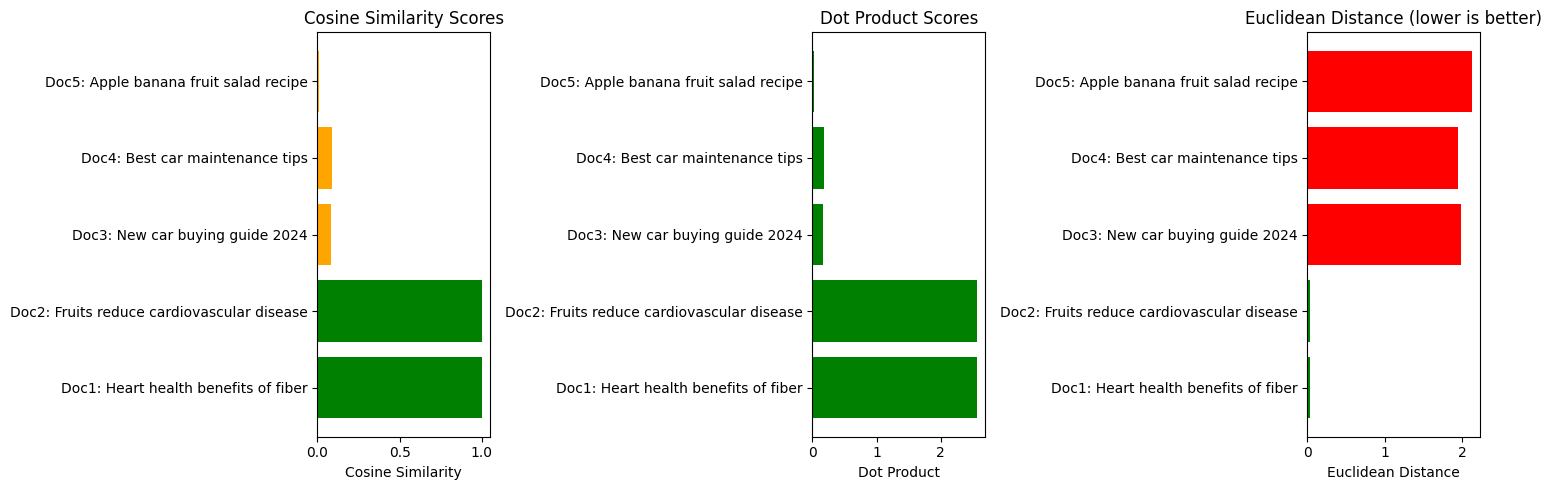

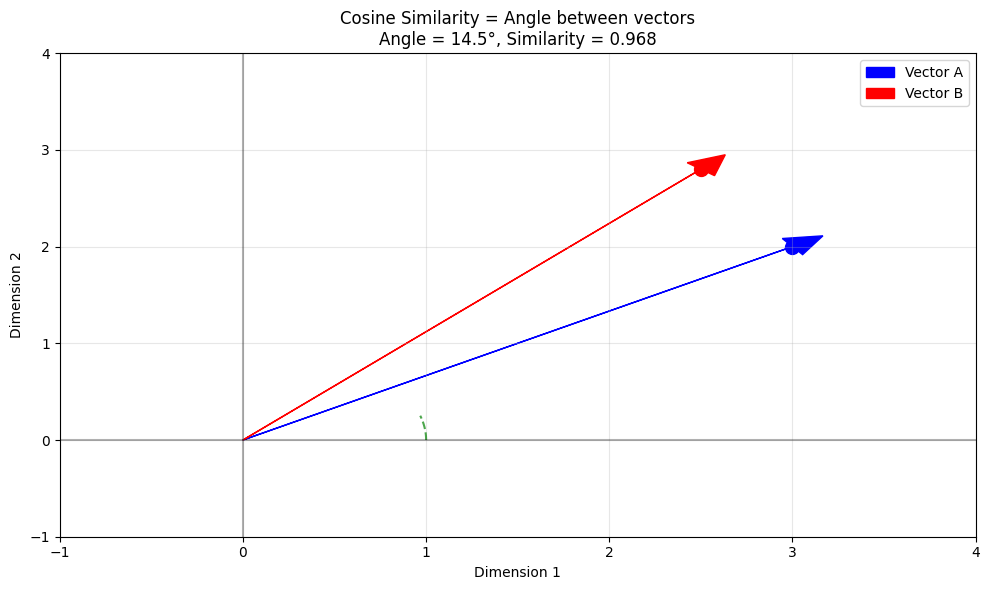

In [9]:
# ============================================================================
# PART 4: SEMANTIC SEARCH & SIMILARITY MEASURES
# ============================================================================


print("\n" + "=" * 60)
print("PART 4: SEMANTIC SEARCH & SIMILARITY MEASURES")
print("=" * 60)


print("""
🔍 SEMANTIC SEARCH: Finding information based on MEANING, not just keywords.
   
   Instead of: "Does document contain word 'car'?"
   We ask:     "Is the document's embedding close to query embedding?"
   
   This works because semantically similar content has similar embeddings!
""")


# Create mock document embeddings
documents = {
    "Doc1: Heart health benefits of fiber": np.array([0.85, 0.80, 0.75, 0.82]),
    "Doc2: Fruits reduce cardiovascular disease": np.array([0.83, 0.78, 0.77, 0.84]),
    "Doc3: New car buying guide 2024": np.array([-0.65, 0.72, -0.58, 0.68]),
    "Doc4: Best car maintenance tips": np.array([-0.62, 0.70, -0.55, 0.65]),
    "Doc5: Apple banana fruit salad recipe": np.array([0.72, -0.68, 0.75, -0.70]),
}


# Query: Health benefits of fruits
query_health = np.array([0.82, 0.79, 0.74, 0.83])


print("\n📝 SEARCH EXAMPLE:")
print(f"Query: 'Health benefits of fruits'")
print(f"Query embedding: {query_health[:3]}...\n")


# 1. COSINE SIMILARITY (Most common for semantic search)
print("=" * 50)
print("1️⃣ COSINE SIMILARITY")
print("=" * 50)
print("Measures the angle between vectors (direction, not magnitude)")
print("Range: -1 to 1 (higher = more similar)")


cosine_scores = {}
for doc_name, doc_vec in documents.items():
    similarity = cosine_similarity([query_health], [doc_vec])[0][0]
    cosine_scores[doc_name] = similarity
    print(f"  {doc_name[:40]:40} → {similarity:.4f}")


# 2. DOT PRODUCT
print("\n" + "=" * 50)
print("2️⃣ DOT PRODUCT")
print("=" * 50)
print("Measures both magnitude and direction")
print("Higher positive value = more similar")


dot_scores = {}
for doc_name, doc_vec in documents.items():
    dot_product = np.dot(query_health, doc_vec)
    dot_scores[doc_name] = dot_product
    print(f"  {doc_name[:40]:40} → {dot_product:.4f}")


# 3. EUCLIDEAN DISTANCE
print("\n" + "=" * 50)
print("3️⃣ EUCLIDEAN DISTANCE")
print("=" * 50)
print("Measures straight-line distance between points")
print("Smaller distance = more similar")


euclidean_scores = {}
for doc_name, doc_vec in documents.items():
    distance = np.linalg.norm(query_health - doc_vec)
    euclidean_scores[doc_name] = distance
    print(f"  {doc_name[:40]:40} → {distance:.4f}")


# --- VISUALIZATION: Similarity Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# Cosine similarity visualization
docs = list(cosine_scores.keys())
cosine_vals = list(cosine_scores.values())
colors_cosine = ['green' if v > 0.7 else 'orange' if v > 0 else 'red' for v in cosine_vals]
axes[0].barh(docs, cosine_vals, color=colors_cosine)
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_title('Cosine Similarity Scores')
axes[0].axvline(x=0, color='black', linestyle='-', alpha=0.3)


# Dot product visualization
dot_vals = list(dot_scores.values())
colors_dot = ['green' if v > 0 else 'red' for v in dot_vals]
axes[1].barh(docs, dot_vals, color=colors_dot)
axes[1].set_xlabel('Dot Product')
axes[1].set_title('Dot Product Scores')
axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.3)


# Euclidean distance visualization
euclidean_vals = list(euclidean_scores.values())
colors_euc = ['green' if v < 1.0 else 'orange' if v < 1.5 else 'red' for v in euclidean_vals]
axes[2].barh(docs, euclidean_vals, color=colors_euc)
axes[2].set_xlabel('Euclidean Distance')
axes[2].set_title('Euclidean Distance (lower is better)')


plt.tight_layout()
plt.show()


# --- Cosine Similarity Formula Visualization ---
fig, ax = plt.subplots(figsize=(10, 6))


# Create two vectors for visualization
vec_a = np.array([3, 2])
vec_b = np.array([2.5, 2.8])


# Calculate cosine similarity
cos_sim = np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
angle = np.arccos(cos_sim) * 180 / np.pi


# Plot vectors
ax.arrow(0, 0, vec_a[0], vec_a[1], head_width=0.2, head_length=0.2, 
         fc='blue', ec='blue', label=f'Vector A')
ax.arrow(0, 0, vec_b[0], vec_b[1], head_width=0.2, head_length=0.2, 
         fc='red', ec='red', label=f'Vector B')


# Add angle arc
theta = np.linspace(0, np.arccos(cos_sim), 100)
radius = 1.0
arc_x = radius * np.cos(theta)
arc_y = radius * np.sin(theta)
ax.plot(arc_x, arc_y, 'green', linestyle='--', alpha=0.7)


ax.scatter(vec_a[0], vec_a[1], color='blue', s=100)
ax.scatter(vec_b[0], vec_b[1], color='red', s=100)


ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title(f'Cosine Similarity = Angle between vectors\nAngle = {angle:.1f}°, Similarity = {cos_sim:.3f}')
ax.grid(True, alpha=0.3)
ax.legend()
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)


plt.tight_layout()
plt.show()



PART 5: KEYWORD SEARCH vs SEMANTIC SEARCH

🔍 SEARCH COMPARISON
Query: 'fruits and vegetables good for heart'

📌 KEYWORD SEARCH (matches exact words):
  Doc D: Heart healthy diet includes vegetables and whole g → 3 matches
  Doc A: Eating fiber reduces heart attack risk             → 1 matches
  Doc B: Consuming fruits lowers cardiovascular disease cha → 1 matches
  Doc C: New electric car has amazing battery life          → 0 matches

🧠 SEMANTIC SEARCH (matches meaning):
  Doc A: Eating fiber reduces heart attack risk             → similarity: 0.9999
  Doc B: Consuming fruits lowers cardiovascular disease cha → similarity: 0.9998
  Doc D: Heart healthy diet includes vegetables and whole g → similarity: 0.9997
  Doc C: New electric car has amazing battery life          → similarity: 0.0406


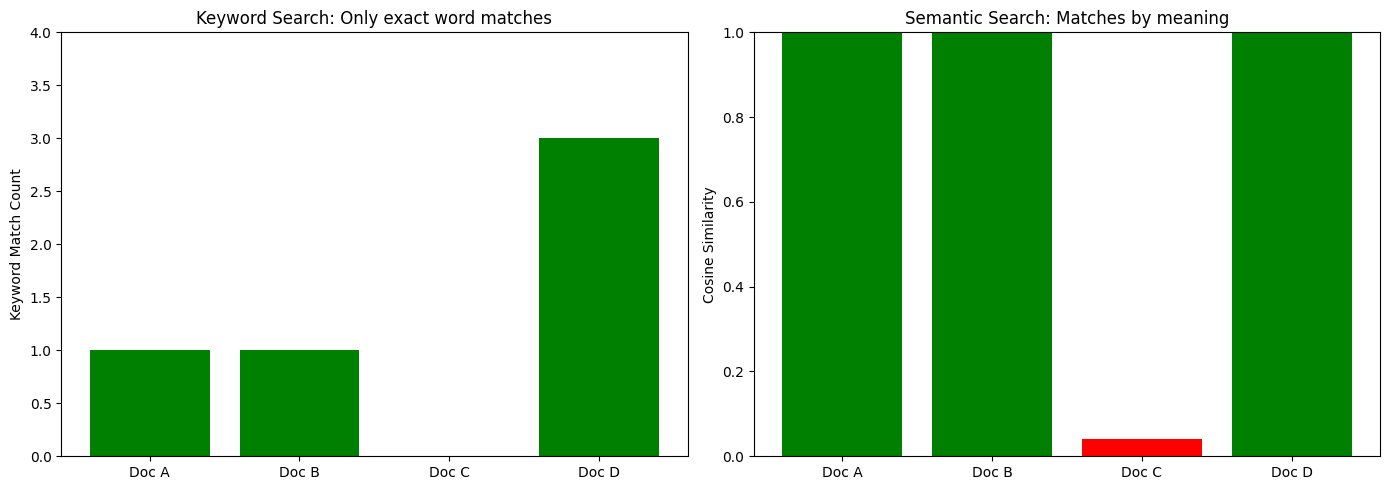


💡 KEY INSIGHT:
   Keyword search FAILED to find relevant docs (Doc A, B, D) because
   they use different words but same meaning!
   Semantic search successfully grouped all heart-health documents together!

PART 6: REAL-WORLD APPLICATIONS

📱 APPLICATIONS OF EMBEDDINGS & SEMANTIC SEARCH:

  🔍 Semantic Search: Google, Bing - finding meaning, not just keywords
  🎬 Recommendation Systems: Netflix, Amazon, Spotify - 'similar to what you liked'
  🖼️ Image Search: Pinterest, Google Images - 'find images like this'
  📚 RAG (Retrieval-Augmented Generation): ChatGPT with knowledge base - answering from documents
  🏷️ Topic Modeling: News categorization, document clustering
  🤖 Chatbots: Understanding user intent, not just commands

📚 RAG (Retrieval-Augmented Generation) Example

User Query: 'How do we measure similarity between embeddings?'

Retrieved relevant documents:
  📄 doc2: 'Embeddings convert text to numerical vectors' (score: 0.998)
  📄 doc3: 'Cosine similarity measures semantic simil

C:\Users\SUBODH\AppData\Local\Temp\ipykernel_21432\4288436871.py:232: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
f:\GenAIByKrishNaik\Full-Stack-GenAI-Bootcamp-1.0\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


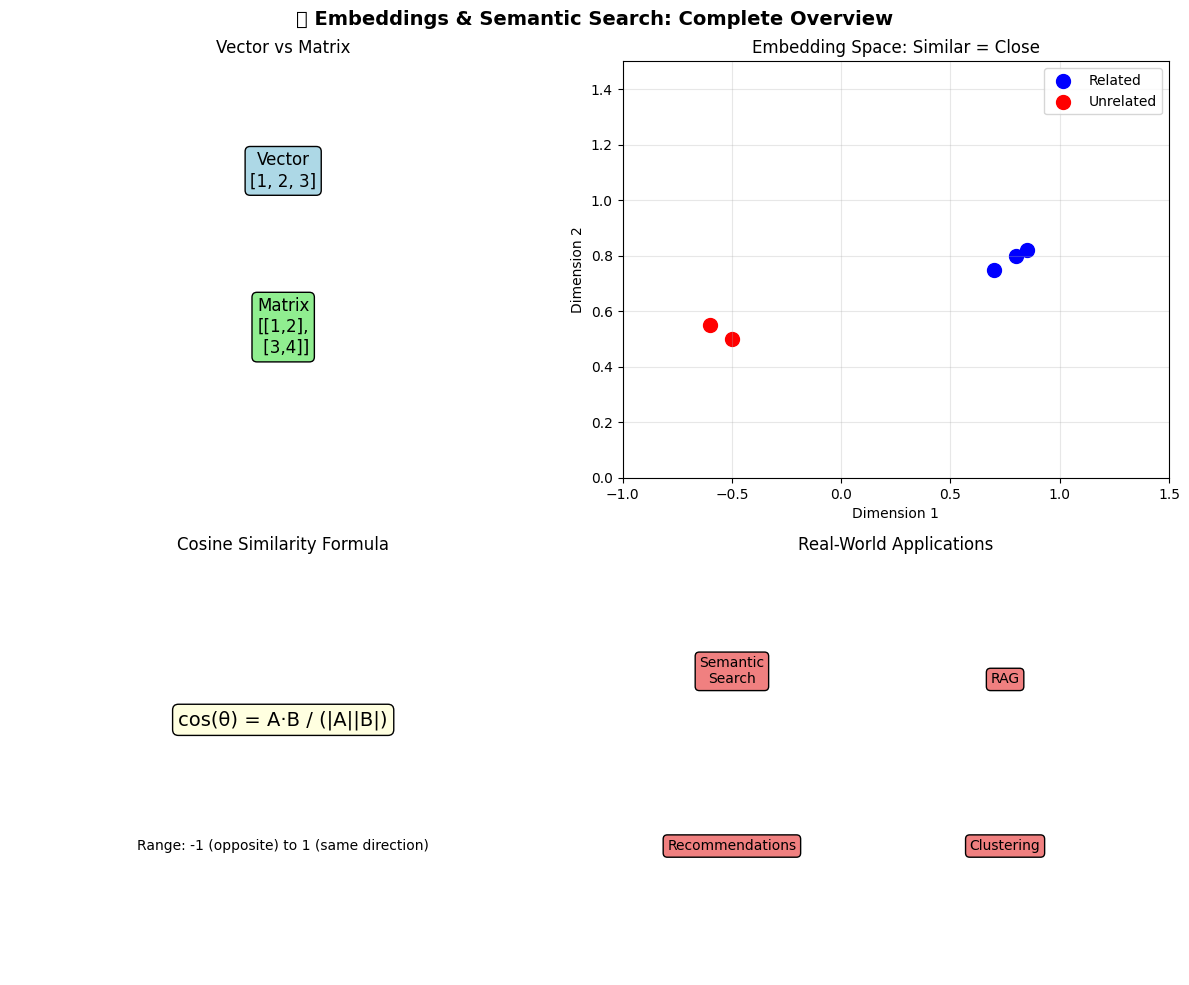


✅ COMPLETE! You now have working code and visualizations for:
   • Vectors and matrices fundamentals
   • Word embeddings and semantic relationships
   • Static vs contextual embeddings
   • Cosine similarity, dot product, Euclidean distance
   • Keyword search vs semantic search
   • Real-world applications (RAG, recommendations, etc.)


In [10]:
# ============================================================================
# PART 5: KEYWORD SEARCH vs SEMANTIC SEARCH
# ============================================================================


print("\n" + "=" * 60)
print("PART 5: KEYWORD SEARCH vs SEMANTIC SEARCH")
print("=" * 60)


# Create a simple search function
def keyword_search(query, documents):
    """Traditional keyword search"""
    query_words = set(query.lower().split())
    results = {}
    for doc_name, doc_text in documents.items():
        doc_words = set(doc_text.lower().split())
        matches = len(query_words & doc_words)
        results[doc_name] = matches
    return results


def semantic_search(query_embedding, document_embeddings):
    """Modern semantic search using embeddings"""
    results = {}
    for doc_name, doc_embedding in document_embeddings.items():
        similarity = cosine_similarity([query_embedding], [doc_embedding])[0][0]
        results[doc_name] = similarity
    return results


# Sample documents
sample_docs = {
    "Doc A": "Eating fiber reduces heart attack risk",
    "Doc B": "Consuming fruits lowers cardiovascular disease chances",
    "Doc C": "New electric car has amazing battery life",
    "Doc D": "Heart healthy diet includes vegetables and whole grains"
}


# Create mock embeddings for these documents
doc_embeddings = {
    "Doc A": np.array([0.85, 0.80, 0.75, 0.82]),
    "Doc B": np.array([0.83, 0.78, 0.77, 0.84]),
    "Doc C": np.array([-0.70, 0.65, -0.60, 0.72]),
    "Doc D": np.array([0.80, 0.82, 0.73, 0.79])
}


# Query: Same meaning but different words
query_text = "fruits and vegetables good for heart"
query_embedding = np.array([0.81, 0.79, 0.74, 0.81])


print("\n🔍 SEARCH COMPARISON")
print(f"Query: '{query_text}'\n")


# Keyword search results
print("📌 KEYWORD SEARCH (matches exact words):")
keyword_results = keyword_search(query_text, sample_docs)
for doc, score in sorted(keyword_results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {doc}: {sample_docs[doc][:50]:50} → {score} matches")


# Semantic search results
print("\n🧠 SEMANTIC SEARCH (matches meaning):")
semantic_results = semantic_search(query_embedding, doc_embeddings)
for doc, score in sorted(semantic_results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {doc}: {sample_docs[doc][:50]:50} → similarity: {score:.4f}")


# --- VISUALIZATION: Search Results Comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


# Keyword search results
docs_names = list(keyword_results.keys())
keyword_vals = list(keyword_results.values())
colors_kw = ['green' if v > 0 else 'red' for v in keyword_vals]
ax1.bar(docs_names, keyword_vals, color=colors_kw)
ax1.set_ylabel('Keyword Match Count')
ax1.set_title('Keyword Search: Only exact word matches')
ax1.set_ylim(0, max(keyword_vals) + 1)


# Semantic search results
semantic_vals = list(semantic_results.values())
colors_sem = ['green' if v > 0.7 else 'orange' if v > 0.5 else 'red' for v in semantic_vals]
ax2.bar(docs_names, semantic_vals, color=colors_sem)
ax2.set_ylabel('Cosine Similarity')
ax2.set_title('Semantic Search: Matches by meaning')
ax2.set_ylim(0, 1)


plt.tight_layout()
plt.show()


print("\n💡 KEY INSIGHT:")
print("   Keyword search FAILED to find relevant docs (Doc A, B, D) because")
print("   they use different words but same meaning!")
print("   Semantic search successfully grouped all heart-health documents together!")




# ============================================================================
# PART 6: REAL-WORLD APPLICATIONS
# ============================================================================


print("\n" + "=" * 60)
print("PART 6: REAL-WORLD APPLICATIONS")
print("=" * 60)


applications = {
    "🔍 Semantic Search": "Google, Bing - finding meaning, not just keywords",
    "🎬 Recommendation Systems": "Netflix, Amazon, Spotify - 'similar to what you liked'",
    "🖼️ Image Search": "Pinterest, Google Images - 'find images like this'",
    "📚 RAG (Retrieval-Augmented Generation)": "ChatGPT with knowledge base - answering from documents",
    "🏷️ Topic Modeling": "News categorization, document clustering",
    "🤖 Chatbots": "Understanding user intent, not just commands"
}


print("\n📱 APPLICATIONS OF EMBEDDINGS & SEMANTIC SEARCH:\n")
for app, description in applications.items():
    print(f"  {app}: {description}")


# Simple RAG example
print("\n" + "=" * 50)
print("📚 RAG (Retrieval-Augmented Generation) Example")
print("=" * 50)


knowledge_base = {
    "doc1": "Python is a high-level programming language",
    "doc2": "Embeddings convert text to numerical vectors",
    "doc3": "Cosine similarity measures semantic similarity",
    "doc4": "Transformers are the foundation of modern NLP"
}


# Mock embeddings for knowledge base
kb_embeddings = {
    "doc1": np.array([0.9, 0.1, 0.1, 0.1]),
    "doc2": np.array([0.1, 0.9, 0.8, 0.1]),
    "doc3": np.array([0.1, 0.8, 0.9, 0.1]),
    "doc4": np.array([0.1, 0.1, 0.1, 0.9])
}


def retrieve_relevant_docs(query_embedding, kb_embeddings, top_k=2):
    """Retrieve most relevant documents"""
    scores = {}
    for doc_id, doc_emb in kb_embeddings.items():
        scores[doc_id] = cosine_similarity([query_embedding], [doc_emb])[0][0]
    
    sorted_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_docs[:top_k]


# Query about embeddings
query_about_embeddings = np.array([0.1, 0.85, 0.85, 0.1])
retrieved = retrieve_relevant_docs(query_about_embeddings, kb_embeddings)


print(f"\nUser Query: 'How do we measure similarity between embeddings?'")
print(f"\nRetrieved relevant documents:")
for doc_id, score in retrieved:
    print(f"  📄 {doc_id}: '{knowledge_base[doc_id]}' (score: {score:.3f})")
print(f"\n💡 These retrieved documents would be sent to an LLM to generate the answer!")




# ============================================================================
# SUMMARY VISUALIZATION
# ============================================================================


print("\n" + "=" * 60)
print("📝 SUMMARY: KEY CONCEPTS VISUALIZED")
print("=" * 60)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))


# 1. Vector vs Matrix
axes[0,0].text(0.5, 0.7, "Vector\n[1, 2, 3]", ha='center', fontsize=12, 
               bbox=dict(boxstyle="round", facecolor='lightblue'))
axes[0,0].text(0.5, 0.3, "Matrix\n[[1,2],\n [3,4]]", ha='center', fontsize=12,
               bbox=dict(boxstyle="round", facecolor='lightgreen'))
axes[0,0].set_title("Vector vs Matrix")
axes[0,0].axis('off')


# 2. Embedding Space
axes[0,1].scatter([0.8, 0.7, 0.85], [0.8, 0.75, 0.82], color='blue', s=100, label='Related')
axes[0,1].scatter([-0.5, -0.6], [0.5, 0.55], color='red', s=100, label='Unrelated')
axes[0,1].set_xlim(-1, 1.5)
axes[0,1].set_ylim(0, 1.5)
axes[0,1].set_xlabel('Dimension 1')
axes[0,1].set_ylabel('Dimension 2')
axes[0,1].set_title('Embedding Space: Similar = Close')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# 3. Cosine Similarity
axes[1,0].text(0.5, 0.6, "cos(θ) = A·B / (|A||B|)", ha='center', fontsize=14,
               bbox=dict(boxstyle="round", facecolor='lightyellow'))
axes[1,0].text(0.5, 0.3, "Range: -1 (opposite) to 1 (same direction)", ha='center', fontsize=10)
axes[1,0].set_title("Cosine Similarity Formula")
axes[1,0].axis('off')


# 4. Applications
apps = ["Semantic\nSearch", "RAG", "Recommendations", "Clustering"]
for i, app in enumerate(apps):
    axes[1,1].text(0.2 + (i%2)*0.5, 0.7 - (i//2)*0.4, app, ha='center', fontsize=10,
                   bbox=dict(boxstyle="round", facecolor='lightcoral'))
axes[1,1].set_title("Real-World Applications")
axes[1,1].axis('off')


plt.suptitle("📊 Embeddings & Semantic Search: Complete Overview", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("✅ COMPLETE! You now have working code and visualizations for:")
print("   • Vectors and matrices fundamentals")
print("   • Word embeddings and semantic relationships")
print("   • Static vs contextual embeddings")
print("   • Cosine similarity, dot product, Euclidean distance")
print("   • Keyword search vs semantic search")
print("   • Real-world applications (RAG, recommendations, etc.)")
print("=" * 60)
